In [47]:
import pandas as pd
import numpy as np
from plotnine import *

## Problem 1

The dataset appears to contain different variables describing the average price, total weight (I am assuming pounds) of, and different types of avocados sold on different days in different geographical regions.

## Problem 2

In [48]:
# Read in dataset
avoData = pd.read_csv("data/avocado-updated-2020.csv")

# Convert 'date' col to datetime
avoData["date"] = pd.to_datetime(avoData["date"])

# Rename avocado PLU columns to represent sizes
avoData_clean = avoData.rename(columns={"4046": "small_avocados", "4225": "large_avocados", "4770": "xlarge_avocados"})

# Define list of major regions according to Hass
major_regions = ["California","Great Lakes","Midsouth","Northeast","Plains","South Central","Southeast","West"]

In [49]:
# Determine metro regions and miscellaneous regions
misc_regions = ["Northern New England", "South Carolina", "West Tex/New Mexico"]
metro_regions = [
    geo for geo in avoData_clean["geography"].unique()
    if geo not in (major_regions + misc_regions + ["Total U.S."])
]


In [50]:
# Classify each geography as either Total U.S., Major Region, or Market
def classify_geography(geo):
    if geo == "Total U.S.":
        return "national"
    elif geo in major_regions:
        return "major_region"
    elif geo in metro_regions:
        return "metro"
    else:
        return "misc_region"

avoData_clean["geography_type"] = avoData_clean["geography"].apply(classify_geography)

## Problem 3

In [51]:
(
    avoData_clean[
        (avoData_clean["year"] == 2017) &
        (avoData_clean["type"] == "organic") &
        (avoData_clean["geography_type"] == "major_region")
    ]
    .groupby("geography")["small_avocados"]
    .sum()
    .sort_values(ascending=False)
)



geography
West             1870206.29
South Central    1717104.19
California       1526290.58
Northeast         925832.36
Southeast         285124.34
Great Lakes       202487.68
Midsouth          186395.50
Plains            168583.40
Name: small_avocados, dtype: float64

**The `West` region sold the most total organic, small Hass avocados in 2017**

## Problem 4

In [52]:
# Extract month and day from date col, given that we already have year col
avoData_clean["month"] = avoData_clean["date"].dt.month
avoData_clean["day"] = avoData_clean["date"].dt.day
# If there was no year col already, code would be:
# avoData_clean["year"] = avoData_clean["date"].dt.year

# Sort mean avocado sales by month for national geography_type to prevent double-counting
avoData_clean[avoData_clean["geography_type"] == "national"].groupby("month")["total_volume"].mean().sort_values(ascending=False)

month
5     2.293203e+07
2     2.236790e+07
6     2.144947e+07
4     2.077160e+07
3     2.035640e+07
1     2.011432e+07
7     2.009696e+07
8     1.938566e+07
9     1.847439e+07
10    1.719583e+07
11    1.673651e+07
12    1.645596e+07
Name: total_volume, dtype: float64

**May appears to be the month with the highest average volume of avocado sales**

## Problem 5

In [53]:
# Find five metro regions with highest averages for total_volume
top5 = avoData_clean[avoData_clean["geography_type"] == "metro"].groupby("geography")["total_volume"].mean().nlargest(5).index
# Create subset for top 5 metro regions
top5_data = avoData_clean[avoData_clean["geography"].isin(top5)]
top5

Index(['Los Angeles', 'New York', 'Dallas/Ft. Worth', 'Houston',
       'Phoenix/Tucson'],
      dtype='str', name='geography')

**The top 5 metro area regions that sold the most total avocados are Los Angeles, New York, Dallas/Ft. Worth, Houston, and Phoenix/Tuscon**

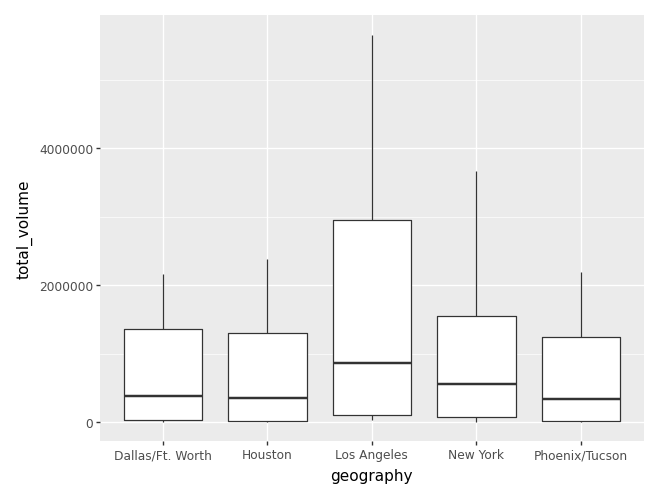

In [54]:
# Create boxplots 
(ggplot(top5_data, aes(x = "geography", y = "total_volume"))
 + geom_boxplot()
)

## Problem 6

In [55]:
# Create list of CA regions
regions_Ca = ["Los Angeles", "San Diego", "San Francisco", "Sacramento"]

# Create subset of only CA regions
avoData_Ca = avoData_clean[avoData_clean["geography"].isin(regions_Ca)]

## Problem 7

In [56]:
# Use for-loop to calculate means, medians, standard deviations, and differences of measurements for each method
results = []
for geo in regions_Ca:
    avg_organic = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "organic")]["average_price"].mean()
    med_organic = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "organic")]["average_price"].median()
    std_organic = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "organic")]["average_price"].std()
    avg_conventional = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "conventional")]["average_price"].mean()
    med_conventional = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "conventional")]["average_price"].median()
    std_conventional = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == "conventional")]["average_price"].std()
    difference_means = avg_organic - avg_conventional
    difference_meds = med_organic - med_conventional
    difference_stds = std_organic - std_conventional

    results.append({
        "ca_region": geo, 
        "avg_organic": avg_organic, "median_organic": med_organic, "std_organic": std_organic,
        "avg_conventional": avg_conventional, "median_conventional": med_conventional, "std_conventional": std_conventional,
        "difference_avgs": difference_means, "difference_medians": difference_meds, "difference_stds": difference_stds
        })

results_table = pd.DataFrame(results)
results_table

,ca_region,avg_organic,median_organic,std_organic,avg_conventional,median_conventional,std_conventional,difference_avgs,difference_medians,difference_stds
0,Los Angeles,1.574902,1.585,0.311722,1.047124,1.02,0.231167,0.527778,0.565,0.080555
1,San Diego,1.798366,1.800,0.331655,1.113856,1.09,0.242960,0.684510,0.710,0.088695
2,San Francisco,2.119444,2.060,0.395854,1.400490,1.39,0.272060,0.718954,0.670,0.123794
3,Sacramento,1.873856,1.840,0.292875,1.295359,1.26,0.219177,0.578497,0.580,0.073698


In [57]:
# Create pivot table showing observation-level price differences between types for plotting
price_diff = (
    avoData_Ca
    .pivot(
        index=["geography", "date"],
        columns="type",
        values="average_price"
    )
    .reset_index()
)
price_diff["price_difference"] = (
    price_diff["organic"]
    - price_diff["conventional"]
)

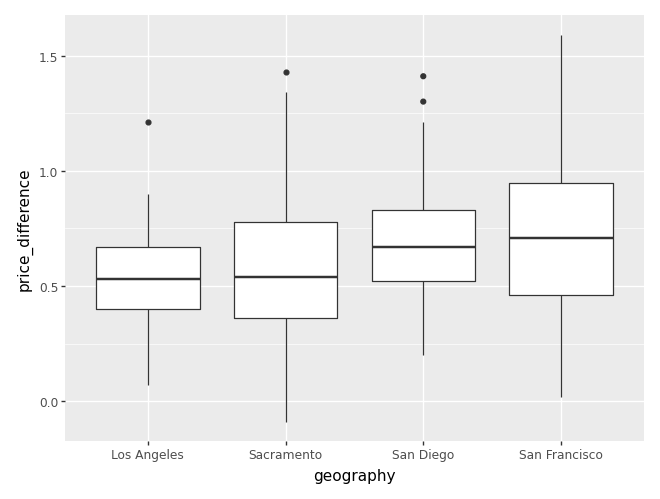

In [58]:
# Plot observational-level price differences
(ggplot(price_diff, aes(x = "geography", y = "price_difference"))
 + geom_boxplot()
 )

## Problem  8

In [59]:

# Create table containing average sales for each size, proportions of sales, and type of avocado
avotypes = ["conventional", "organic"]
results2 = []
for typ in avotypes:
    for geo in regions_Ca:
        avg_small = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == typ)]["small_avocados"].mean()
        avg_large = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == typ)]["large_avocados"].mean()
        avg_xlarge = avoData_Ca[(avoData_Ca["geography"] == geo) & (avoData_Ca["type"] == typ)]["xlarge_avocados"].mean()
        prop_small = avg_small / (avg_small + avg_large + avg_xlarge)
        prop_large = avg_large / (avg_small + avg_large + avg_xlarge)
        prop_xlarge = avg_xlarge / (avg_small + avg_large + avg_xlarge)


        results2.append({
            "ca_region": geo, 
            "avg_small": avg_small, "prop_small": prop_small, 
            "avg_large": avg_large, "prop_large": prop_large,
            "avg_xlarge": avg_xlarge, "prop_xlarge": prop_xlarge,
            "type": typ
            })

results2_table = pd.DataFrame(results2)
results2_table

,ca_region,avg_small,prop_small,avg_large,prop_large,avg_xlarge,prop_xlarge,type
0,Los Angeles,1.172952e+06,0.684389,443842.308562,0.258971,97073.643529,0.056640,conventional
1,San Diego,1.637928e+05,0.508891,140106.101438,0.435298,17963.543497,0.055811,conventional
2,San Francisco,2.158398e+05,0.317342,449377.420359,0.660705,14931.603235,0.021953,conventional
3,Sacramento,1.412831e+05,0.361688,243005.070163,0.622099,6333.279673,0.016213,conventional
4,Los Angeles,1.444206e+04,0.409677,20804.220654,0.590152,6.035294,0.000171,organic
5,San Diego,2.573068e+03,0.261274,7273.784575,0.738592,1.323595,0.000134,organic
6,San Francisco,8.303041e+03,0.422433,11350.098072,0.577457,2.159346,0.000110,organic
7,Sacramento,2.808893e+03,0.396045,4282.693203,0.603846,0.772680,0.000109,organic


In [60]:
# Use melt to reshape to long format
plot_data = results2_table.melt(
    id_vars=["ca_region", "type"],
    value_vars=["prop_small", "prop_large", "prop_xlarge"],
    var_name="size",
    value_name="proportion"
)

# Rename columns
plot_data["size"] = plot_data["size"].replace({
    "prop_small": "Small",
    "prop_large": "Large",
    "prop_xlarge": "Xlarge"
})

# Convert sizes to categorical to help chart order match
plot_data["size"] = pd.Categorical(
    plot_data["size"],
    categories=["Xlarge", "Large", "Small"],
    ordered=True
)

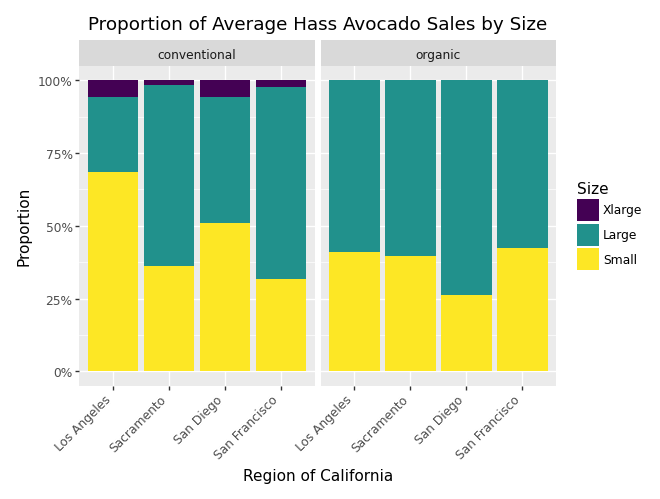

In [61]:
# Create bar plot
(
    ggplot(
        plot_data, aes(
            x = "ca_region",
            y = "proportion",
            fill = "size"
        )
    )
    + geom_col(position="stack")
    + facet_wrap("~type")
    + labs(
        title="Proportion of Average Hass Avocado Sales by Size",
        x = "Region of California",
        y = "Proportion",
        fill = "Size"
    )
    + theme(
    axis_text_x=element_text(rotation=45, hjust=1)
    )
    + scale_y_continuous(
        breaks=[0,.25,.50,.75,1],
        labels=["0%", "25%", "50%", "75%", "100%"]
    )
)

## Problem 9

In [ ]:
# Import Zillow housing data
zillowData = pd.read_csv("data/ZHVI_data.csv")
zillowData.head()

# Filter for only 4 California regions
regions_zillow_ca = ["Los Angeles, CA", "Sacramento, CA", "San Diego, CA", "San Francisco, CA"]
zillowData_Ca = zillowData[zillowData["RegionName"].isin(regions_zillow_ca)]

# Drop unnecessary columns
zillowData_Ca = zillowData_Ca.drop(columns=["RegionID","SizeRank","RegionType","StateName"])

# Reshape in long form
zillowCA_long = zillowData_Ca.melt(
    id_vars=["RegionName"],
    var_name="date",
    value_name="home_value"
)

# Match RegionName entries with Avocado region names
zillowCA_long["RegionName"] = zillowCA_long["RegionName"].str.replace(", CA", "", regex=False)

# Convert date column to datetime and filter for dates in avocado data
zillowCA_long["date"] = pd.to_datetime(zillowCA_long["date"])
zillowCA_long = zillowCA_long[
    (zillowCA_long["date"] >= "2015-01-01") & 
    (zillowCA_long["date"] <= "2020-11-30")
]

# Extract date and month from datetime entries
zillowCA_long["year"] = zillowCA_long["date"].dt.year
zillowCA_long["month"] = zillowCA_long["date"].dt.month


In [ ]:
# Aggregate avocado sales monthly
monthly_avo = (
    avoData_Ca.groupby(["geography", "year", "month", "type"])
    .agg(
        avg_avocado_price=("average_price", "mean"),
        total_avocado_volume=("total_volume", "sum")
    )
    .reset_index()
)

# Rename Region column to geography for merging
zillowCA_long = zillowCA_long.rename(columns={"RegionName": "geography"})

In [ ]:
# Join avocado and housing data
avo_housing_data = monthly_avo.merge(
    zillowCA_long,
    on=["geography", "year", "month"],
    how="left"
)

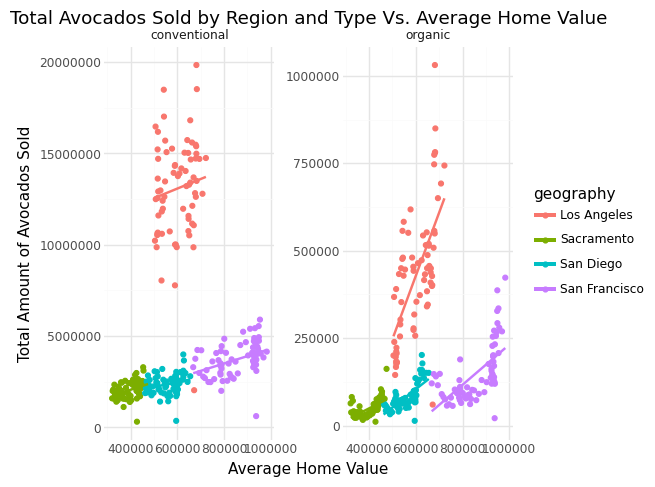

In [ ]:
# Create plot showing avocado sales vs. home value
(
    ggplot(avo_housing_data, aes(x = "home_value", y = "total_avocado_volume", color="geography"))
    + geom_point()
    + facet_wrap('~type', scales="free_y")
    + theme_minimal()
    + geom_smooth(method="lm", se=False)
    + labs(
        title="Total Avocados Sold by Region and Type Vs. Average Home Value",
        x = "Average Home Value",
        y = "Total Amount of Avocados Sold"
    )
)

In [80]:
# Find correlation values between avocado volume and home values by region and type
correlations = (
    avo_housing_data
    .groupby(["geography", "type"])
    .apply(
        lambda x: x["home_value"].corr(x["total_avocado_volume"])
    )
    .reset_index(name="correlation")
)

correlations

,geography,type,correlation
0,Los Angeles,conventional,0.125738
1,Los Angeles,organic,0.641515
2,Sacramento,conventional,0.384347
3,Sacramento,organic,0.581791
4,San Diego,conventional,0.243531
5,San Diego,organic,0.721408
6,San Francisco,conventional,0.394265
7,San Francisco,organic,0.613701


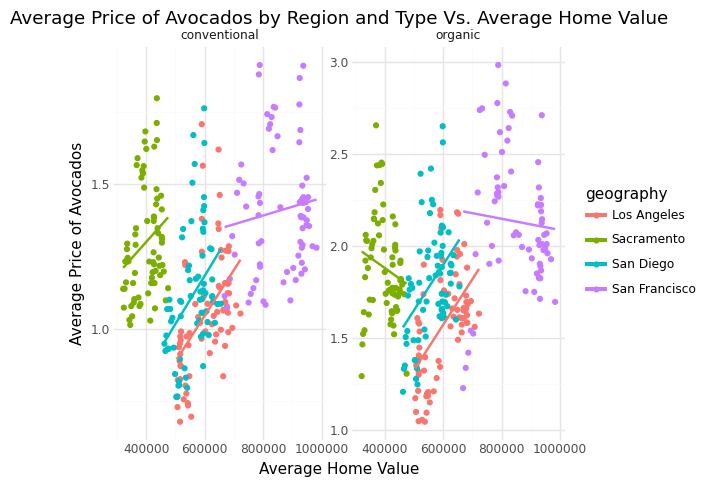

In [ ]:
# Create plot showing avg avocado price vs. home value
(
    ggplot(avo_housing_data, aes(x = "home_value", y = "avg_avocado_price", color="geography"))
    + geom_point()
    + facet_wrap('~type', scales="free_y")
    + theme_minimal()
    + geom_smooth(method="lm", se=False)
    + labs(
        title="Average Price of Avocados by Region and Type Vs. Average Home Value",
        x = "Average Home Value",
        y = "Average Price of Avocados"
    )
)

In [83]:
# Find correlation values between average avocado price and home values by region and type
correlations2 = (
    avo_housing_data
    .groupby(["geography", "type"])
    .apply(
        lambda x: x["home_value"].corr(x["avg_avocado_price"])
    )
    .reset_index(name="correlation")
)

correlations2

,geography,type,correlation
0,Los Angeles,conventional,0.487781
1,Los Angeles,organic,0.551383
2,Sacramento,conventional,0.255294
3,Sacramento,organic,-0.179295
4,San Diego,conventional,0.391811
5,San Diego,organic,0.423766
6,San Francisco,conventional,0.120988
7,San Francisco,organic,-0.074229


**Across the four California regions, higher home values were generally more consistently associated with higher avocado sales rather than with higher average avocado prices. This pattern was especially strong for organic avocados, where the correlations between home value and sales volume were moderately strong in all four regions, whereas conventional avocado sales demonstrated weaker positive relationships. This suggests that as home values increased, organic avocado consumption also tended to increase somewhat, though the strength of that relationship varied by region.**

**The relationship between home values and average avocado prices was much less consistent. Conventional prices were generally positively correlated with home values, but mostly weakly or moderately, while organic prices showed mixed relationships between the regions. Overall the data suggests that higher-value housing markets are more closely associated with greater avocado purchasing, especially organic avocados, than with higher avocado prices.**